ML

ML modeling & evaluation

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, precision_recall_curve)
from xgboost import XGBClassifier
import shap

# Install SHAP if not available
!pip install shap -q

# Style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load features
project_path = '/content/drive/MyDrive/credit-risk-germany'
conn = sqlite3.connect(f'{project_path}/data/processed/credit_risk.db')
df = pd.read_sql('SELECT * FROM loans_features', conn)

print("Shape:", df.shape)
df.head()

Shape: (1000, 29)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,foreign_worker,credit_risk,credit_per_month,age_group,is_long_term_loan,default_flag,debt_burden,employment_score,savings_score,high_risk_profile
0,< 0 DM,6,critical account / other credits existing,radio/television,1169,unknown / no savings account,>= 7 years,4,male: single,none,...,yes,good,194.833333,50+,0,0,46.76,4,0,0
1,0 to 200 DM,48,existing credits paid duly till now,radio/television,5951,< 100 DM,1 to 4 years,2,female: divorced/separated/married,none,...,yes,bad,123.979167,18-25,1,1,119.02,2,1,0
2,no checking account,12,critical account / other credits existing,education,2096,< 100 DM,4 to 7 years,2,male: single,none,...,yes,good,174.666667,36-50,0,0,41.92,3,1,0
3,< 0 DM,42,existing credits paid duly till now,furniture/equipment,7882,< 100 DM,4 to 7 years,2,male: single,guarantor,...,yes,good,187.666667,36-50,1,0,157.64,3,1,0
4,< 0 DM,24,delay in paying off in the past,new car,4870,< 100 DM,1 to 4 years,3,male: single,none,...,yes,bad,202.916667,50+,0,1,146.10,2,1,0


In [45]:
# Drop non-feature columns
drop_cols = ['credit_risk', 'age_group']  # age_group is already encoded via age
X = df.drop(columns=drop_cols + ['default_flag'])
y = df['default_flag']



In [46]:

# Encode all remaining categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))


In [47]:
# Train/test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Default rate in train: {y_train.mean():.1%}")
print(f"Default rate in test:  {y_test.mean():.1%}")

Training set: 800 rows
Test set:     200 rows
Default rate in train: 30.0%
Default rate in test:  30.0%


Applying Logistic Regression

In [48]:
# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [49]:
# Train
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [50]:
# Predict
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_probs)

print(f"Logistic Regression ROC-AUC: {lr_auc:.4f}")
print(f"Gini Coefficient:            {2 * lr_auc - 1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr.predict(X_test_scaled),
                             target_names=['Good', 'Bad']))

Logistic Regression ROC-AUC: 0.7305
Gini Coefficient:            0.4610

Classification Report:
              precision    recall  f1-score   support

        Good       0.77      0.86      0.81       140
         Bad       0.56      0.40      0.47        60

    accuracy                           0.72       200
   macro avg       0.66      0.63      0.64       200
weighted avg       0.71      0.72      0.71       200



Applying XGBoost

In [51]:
# Train XGBoost — scale_pos_weight handles class imbalance
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [52]:
# Predict
xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_probs)

print(f"XGBoost ROC-AUC:  {xgb_auc:.4f}")
print(f"Gini Coefficient: {2 * xgb_auc - 1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb.predict(X_test),
                             target_names=['Good', 'Bad']))

XGBoost ROC-AUC:  0.7871
Gini Coefficient: 0.5743

Classification Report:
              precision    recall  f1-score   support

        Good       0.83      0.76      0.79       140
         Bad       0.53      0.65      0.59        60

    accuracy                           0.72       200
   macro avg       0.68      0.70      0.69       200
weighted avg       0.74      0.72      0.73       200



Compare models visually with ROC curves

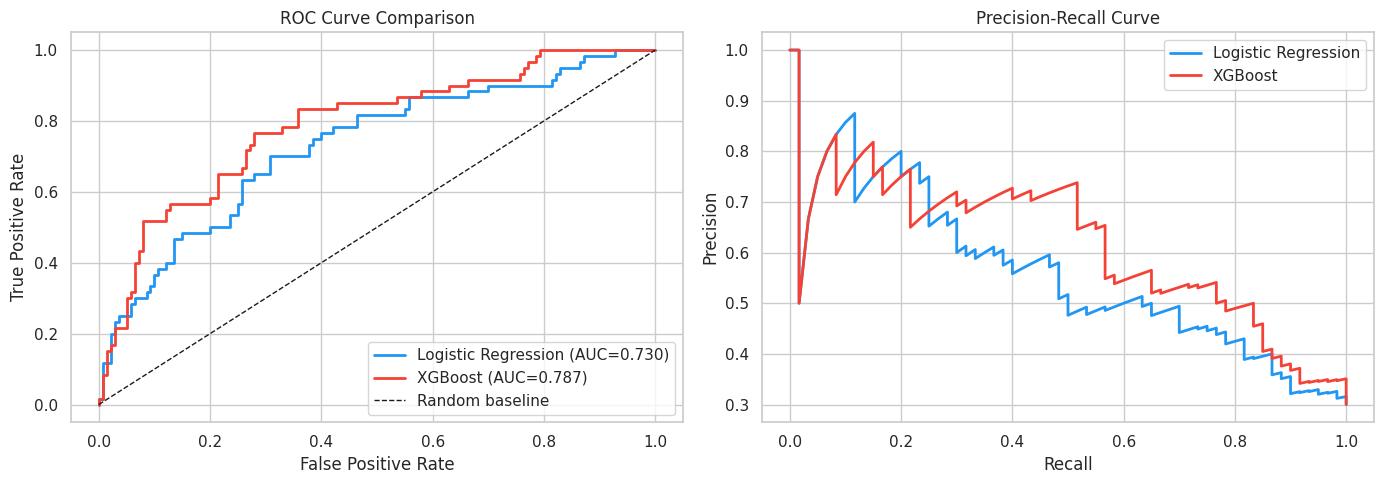

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
for name, probs, color in [('Logistic Regression', lr_probs, '#2196F3'),
                             ('XGBoost', xgb_probs, '#F44336')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random baseline')
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# --- Precision-Recall Curve ---
for name, probs, color in [('Logistic Regression', lr_probs, '#2196F3'),
                             ('XGBoost', xgb_probs, '#F44336')]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(rec, prec, label=name, color=color, lw=2)

axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{project_path}/reports/06_roc_pr_curves.png', dpi=150)
plt.show()

Confusion metricx

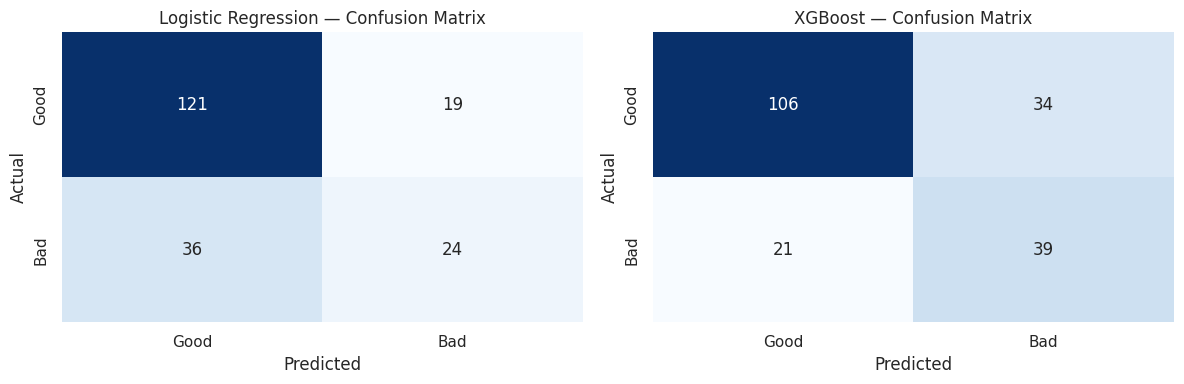

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, preds in [
    (axes[0], 'Logistic Regression', lr.predict(X_test_scaled)),
    (axes[1], 'XGBoost', xgb.predict(X_test))
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['Good','Bad'],
                yticklabels=['Good','Bad'])
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{project_path}/reports/07_confusion_matrices.png', dpi=150)
plt.show()

SHAP explainability

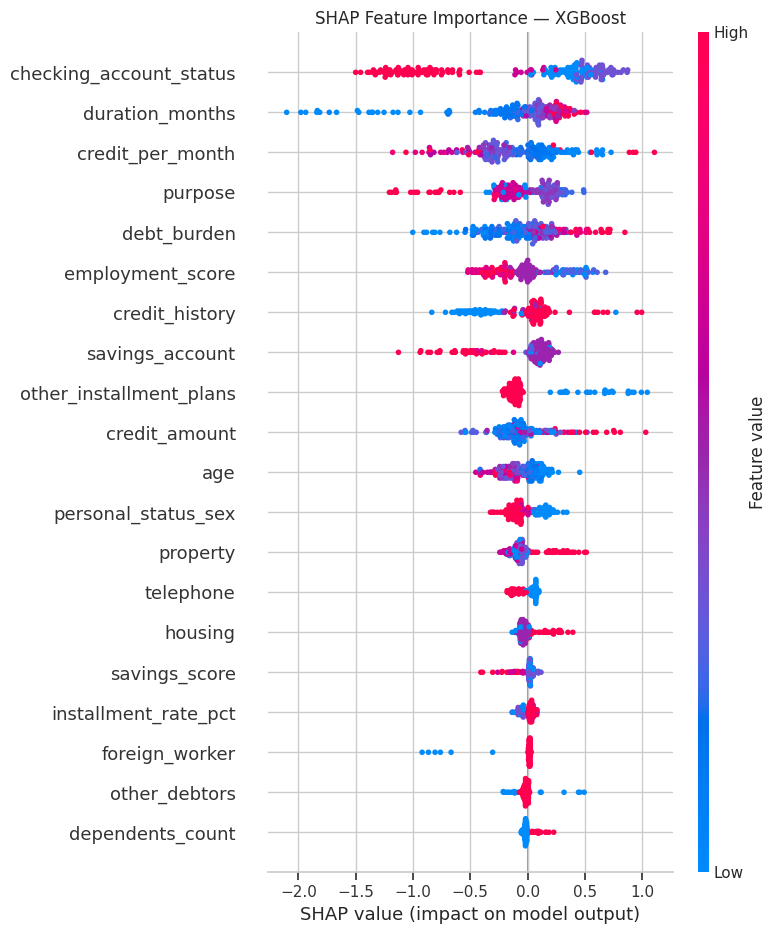

In [64]:
# SHAP values for XGBoost
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot — shows which features drive predictions most
plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title('SHAP Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig(f'{project_path}/reports/08_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

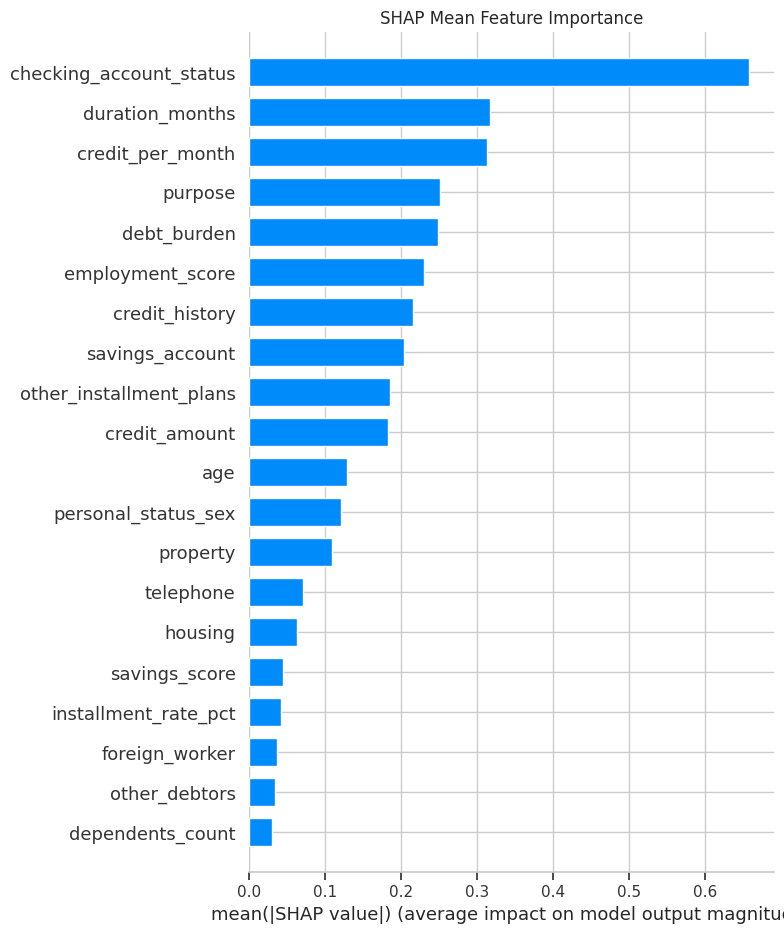

In [65]:
# Bar plot version — cleaner for presentations and Power BI screenshots
plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP Mean Feature Importance')
plt.tight_layout()
plt.savefig(f'{project_path}/reports/09_shap_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()

Assign risk tiers

In [66]:
# Use XGBoost probabilities to assign risk tiers
df_results = X_test.copy()
df_results['actual_default']    = y_test.values
df_results['default_probability'] = xgb_probs

df_results['risk_tier'] = pd.cut(
    df_results['default_probability'],
    bins=[0, 0.2, 0.4, 0.6, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Summarise risk tiers
tier_summary = df_results.groupby('risk_tier', observed=True).agg(
    count=('actual_default', 'count'),
    actual_default_rate=('actual_default', 'mean')
).round(3)

print(tier_summary)

# Save full results
df_results.to_csv(f'{project_path}/data/processed/model_results.csv', index=False)
print("\nResults saved to model_results.csv")

           count  actual_default_rate
risk_tier                            
Low           72                0.111
Medium        41                0.146
High          28                0.429
Very High     59                0.576

Results saved to model_results.csv


Saving evaluation summary

In [67]:
summary = {
    'Model': ['Logistic Regression', 'XGBoost'],
    'ROC-AUC': [round(lr_auc, 4), round(xgb_auc, 4)],
    'Gini':    [round(2*lr_auc-1, 4), round(2*xgb_auc-1, 4)],
}
summary_df = pd.DataFrame(summary)
summary_df.to_csv(f'{project_path}/reports/model_evaluation_summary.csv', index=False)
print(summary_df)

                 Model  ROC-AUC    Gini
0  Logistic Regression   0.7305  0.4610
1              XGBoost   0.7871  0.5743
